Enter x1: 1
Enter y1: 7
Enter x2: 11
Enter y2: 7

--- Bresenham's Line Algorithm ---
Starting point: (1, 7)
Ending point: (11, 7)
dx = 10  dy = 0
sx = 1  sy = -1 

Case: Shallow line (dx > dy).

Initial decision parameter p = -10 

step 0 p = -10 pixels -> (1, 7)
step 1 p = -10 pixels -> (2, 7)
step 2 p = -10 pixels -> (3, 7)
step 3 p = -10 pixels -> (4, 7)
step 4 p = -10 pixels -> (5, 7)
step 5 p = -10 pixels -> (6, 7)
step 6 p = -10 pixels -> (7, 7)
step 7 p = -10 pixels -> (8, 7)
step 8 p = -10 pixels -> (9, 7)
step 9 p = -10 pixels -> (10, 7)
step 10 p = -10 pixels -> (11, 7)


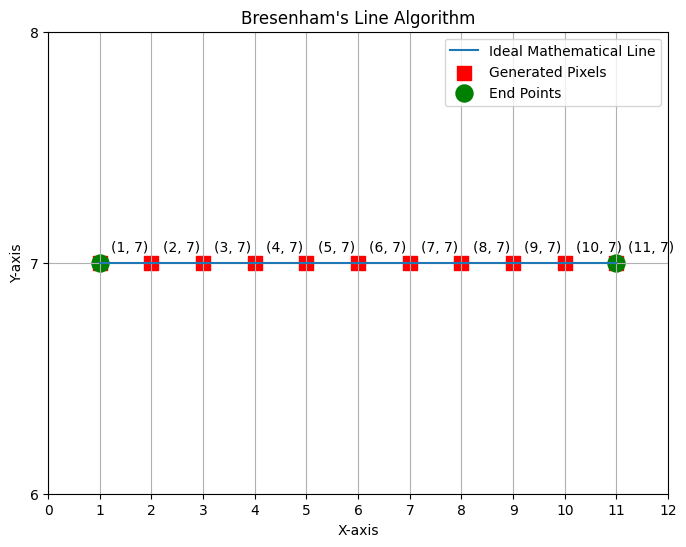

In [1]:
import matplotlib.pyplot as plt

def bresenham_line(x1, y1, x2, y2):
    pixels = []
    print("\n--- Bresenham's Line Algorithm ---")
    print("Starting point:", (x1, y1))
    print("Ending point:", (x2, y2))

    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    sx = 1 if x2 > x1 else -1
    sy = 1 if y2 > y1 else -1

    x, y = x1, y1

    print("dx =", dx, " dy =", dy)
    print("sx =", sx, " sy =", sy, "\n")

    # Case: gentle slope (|m| <= 1)
    if dx > dy:
        print("Case: Shallow line (dx > dy).\n")
        p = 2 * dy - dx
        print("Initial decision parameter p =", p, "\n")

        for i in range(dx + 1):
            pixels.append((x, y))
            print(
                "step", i,
                "p =", p,
                "pixels ->", (x, y)
            )

            if p >= 0:
                y += sy
                p -= 2 * dx
            x += sx
            p += 2 * dy

    # Case: steep slope (|m| > 1)
    else:
        print("Case: Steep line (dy >= dx).\n")
        p = 2 * dx - dy
        print("Initial decision parameter p =", p, "\n")

        for i in range(dy + 1):
            pixels.append((x, y))
            print(
                "step", i,
                "p =", p,
                "pixels ->", (x, y)
            )

            if p >= 0:
                x += sx
                p -= 2 * dy
            y += sy
            p += 2 * dx

    return pixels


x1 = int(input("Enter x1: "))
y1 = int(input("Enter y1: "))

x2 = int(input("Enter x2: "))
y2 = int(input("Enter y2: "))

# calling function
pixels = bresenham_line(x1, y1, x2, y2)

# Plotting
x_pixels = [p[0] for p in pixels]
y_pixels = [p[1] for p in pixels]

plt.figure(figsize=(8, 6))

# Ideal mathematical line
plt.plot(
    [x1, x2],
    [y1, y2],
    label="Ideal Mathematical Line"
)

# Generated pixels
plt.scatter(
    x_pixels,
    y_pixels,
    s=100,
    marker="s",
    color="red",
    label="Generated Pixels"
)

# End points
plt.scatter(
    [x1, x2],
    [y1, y2],
    s=150,
    marker="o",
    color="green",
    label="End Points"
)

# Label each generated pixel
for x, y in pixels:
    plt.annotate(
        f"({x}, {y})",
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10
    )

# Axis settings
plt.xticks(range(min(x1, x2) - 1, max(x1, x2) + 2))
plt.yticks(range(min(y1, y2) - 1, max(y1, y2) + 2))
plt.grid(True)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Bresenham's Line Algorithm")
plt.legend()
plt.show()